# Treatment Effects with Panel Data
## Difference-in-differences

Now that we've gone through the introduction to panel data esitmators in the last notebook, it's time to look at a common estimator - **Difference-in-differences (DiD)**. 

DiD is a quasi-experimental method that is often employed to estimate a causal effect when randomisation is not possible. It requries a panel / longitudinal dataset that follows multiple units (at least two) over time. 

At a high level, DiD compares the outcomes of a group that recieves some treatment (say an increase in the excise tax on tabacco to pick one random example), to another group that does not recieve that treatment. I will refer to these groups as the treatment and control groups respectively. 

A bit more specifically, the DiD estimator compares the mean of each groups outcome both before and after the treatment is applied (hence the name, difference-in-differences).

Now that seems like quite a simple approach (and it is), however it requires some key assumptions. 

The most essential of these assumptions is the known as the "parallel trends" assumption. This requires that there are no "time-varying" characteristics that are different between the two groups that could explain the differences in the outcomes. For example, one group might experience a recession in the economy whilst the other didn't. 

This is the essential assumption. If there are some unobserved effect that impact the groups across time, the estimated effect cannot be entirely attributed to the treatment itself (it's possible that time-varying difference explain the change in outcome instead). 

Now, that is probably a little confusing at this stage. So the best way to learn is to look at an example! 

Let's return to the example of the California Excise tax on Tabacoo that we explored in the time series notebook. 

To refresh quickly in 1989, proposition 99 was enacted that increased the excise tax on cigarettes by 25 cents per pack. In theory, this increase in cost should decrease the number of cigarettes consumed. That is a testable statement. 

Now, really handily this excise tax was only enacted in California, yet all the other states in the US did not enact this excise tax. These states are a potential pool of control "units".

So, now that we know a bit more about panel data, we can compare the time series of cigarette sales per capita before and after intervention in both California (where the treatment occoured i.e. treatment group) and those states where there was no increase in the excise on tabaco (the control group).

With this set up lets show how we can calculate the DiD estimator.

In [1]:
%reset -f

Let's start by loading in the necessary packages for this notebook.

In [2]:
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm
import linearmodels as lm
import seaborn as sns

Next we load in our data:

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

Let's have a quick peak at the data, it's dimensions and add a constant term.

In [4]:
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment
0,1,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False
1,1,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False
2,1,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False
3,1,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False
4,1,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False


In [5]:
df.shape

(1209, 9)

In [6]:
df = sm.add_constant(df)

Next, lets create some variables that will come in handy later on. 

In [7]:
df['treated'] = np.where(df['california'] == True,1,0)
df['post_treat'] = np.where(df['after_treatment'] == True,1,0)
df['treated_post_treat'] = df['treated']*df['post_treat']
df = pd.concat([df,pd.get_dummies(df['year'], prefix = "year").astype(int)], axis = 1)

# How do we calculate the DiD Estimator?
## Intervention Timeline

The first step in good DiD implementation is to visually check the parallel trends assumption. There are a few ways to do this, however the simplest is to comapre each units time series for the outcome variable, `cigsales` in our example representing cigarette sales per capita.

If we plot each of the states cigarette sales per capita over the available years and compare this too California (in red) time series, we can see that there is qutie a bit of difference across the states. 

In fact, California already has one of the lowest Cigarette consumption per capita rates of all the states. 

This might raise a problem. How can we be certain that our esitmates are because the excise was introduced, and not because cigarette sales were already on a downward trend for some unobserved reason? 

/tmp/ipykernel_37450/3647880771.py:2: UserWarning: 
The palette list has fewer values (6) than needed (38) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(y = "cigsale",


Text(0.5, 1.0, 'Historical Cigarette Sales Per Capita by State')

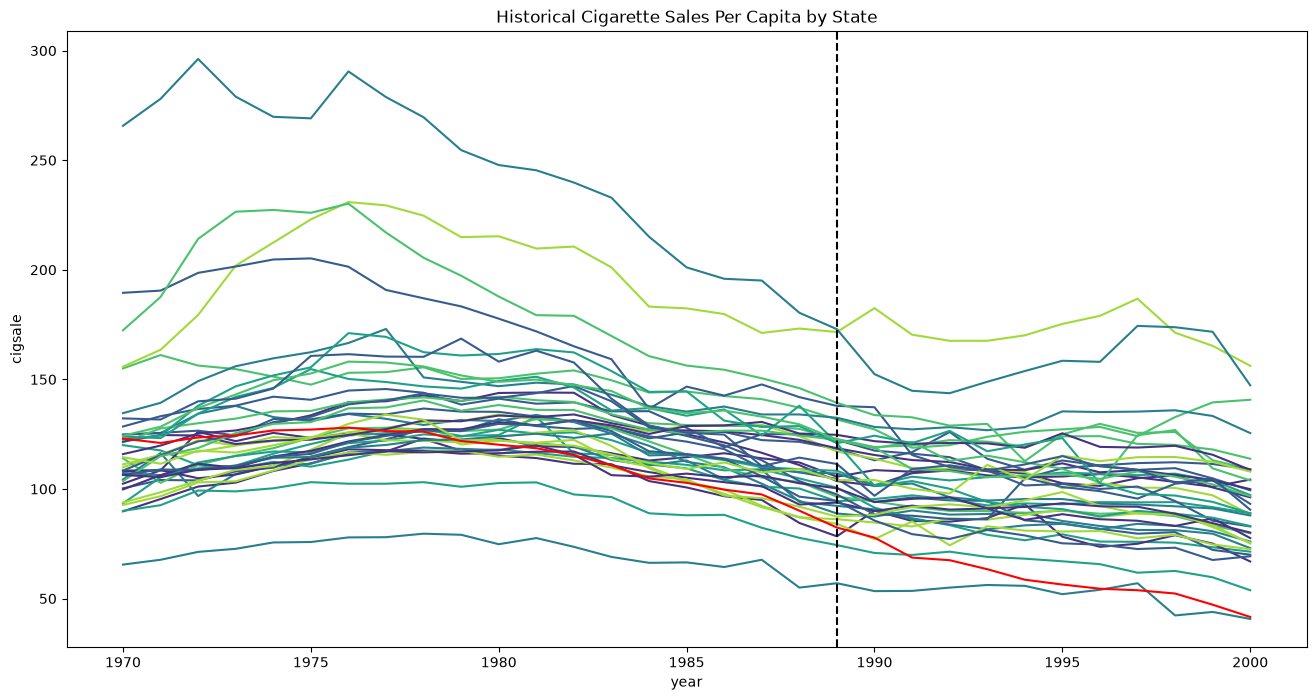

In [8]:
plt.figure(figsize = (16,8))
sns.lineplot(y = "cigsale", 
            x = "year",
            hue = "state",
            data = df[df['california'] == False],
            palette = sns.color_palette("viridis"),
            legend = False)
plt.plot(df[df['california'] == True]['year'], df[df['california'] == True]['cigsale'], color = "red")
plt.axvline(x = 1989, color = "black", linestyle = "--")
plt.title("Historical Cigarette Sales Per Capita by State")
#plt.subtitle("Solid black line is california")

We can simplify the above plot to see if on average the trends between the two groups are different. If we plot the mean of each groups we can see that there does appear to be a different trend between the two groups. 

Now, this means the DiD estimator is probably biased. However, we can still calculate the estimate, noting that this is likely an upper bound of the estimate.

A good question for your learning might be how do we know that this will be an upper bound estimate *(hint: think about where the two trends prior to intervention will end up, and what this might mean for the final estimate)*.

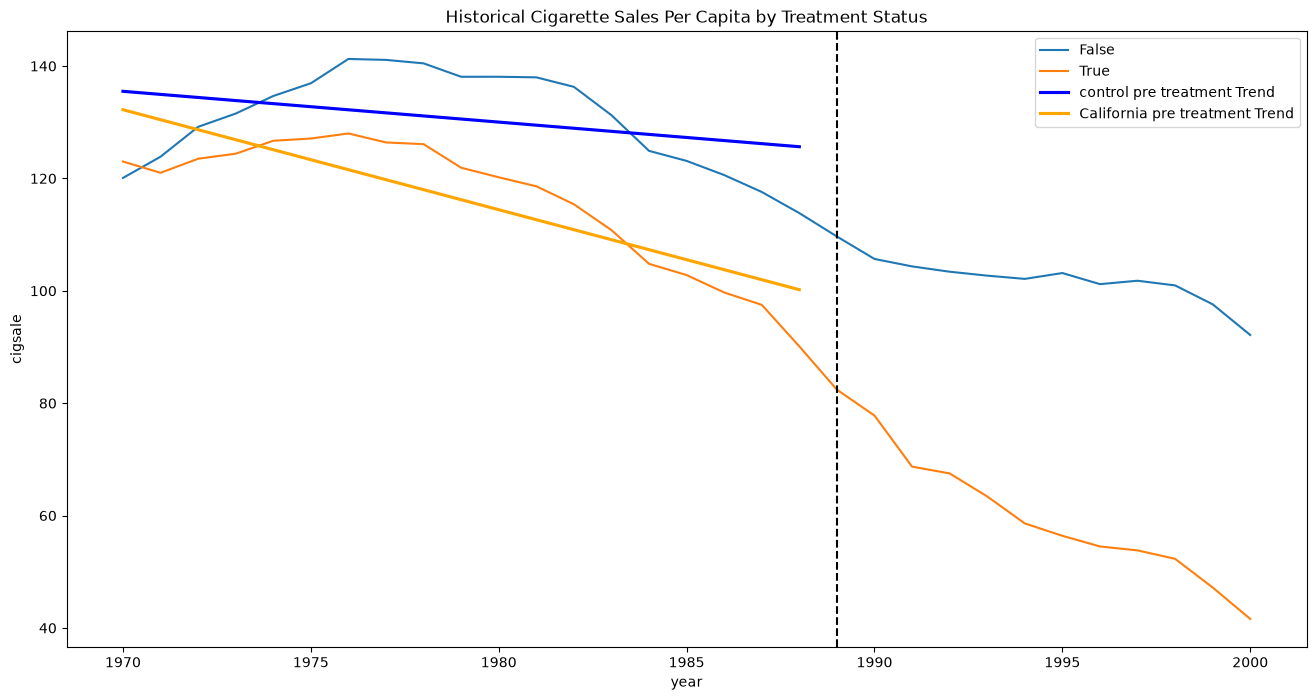

In [9]:
plt.figure(figsize=(16, 8))
sns.lineplot(y = "cigsale", 
            x = "year",
            hue = "california",
            data = df.groupby(['california','year'])['cigsale'].mean().reset_index())
sns.regplot(x="year", y="cigsale", data=df[(df['year'] < 1989) & (df['california'] == False)], scatter=False, 
            color="blue", label="control pre treatment Trend", ci = None)
sns.regplot(x="year", y="cigsale", data=df[(df['year'] < 1989) & (df['california'] == True)], scatter=False, 
            color="orange", label="California pre treatment Trend", ci = None)
plt.axvline(x = 1989, color = "black", linestyle = "--")
plt.title("Historical Cigarette Sales Per Capita by Treatment Status")
plt.title("Historical Cigarette Sales Per Capita by Treatment Status")
plt.legend()
plt.show()

## Manual calculation

Okay, so understanding that there is some bias, lets try get a point estimate anyhow. As mentioned in the introduction, the easiest way to estimate DiD is by comparing the group means pre and post treatment. 

We can set the mean notation as $ \mu_{i,t}$ where $i \in treatment, control$ and where $t \in before\ treatment, after\ treatment$. 

The DiD estimate is then the difference in the treatment means before and after, minus the difference in the control means before and after i.e:

$$ (\mu_{treated,after} - \mu_{treated,before}) - (\mu_{control,after} - \mu_{control,before})$$

This is quite easy to code up:

In [10]:
mu_after_treat = df.loc[(df['treated'] == 1) & (df['post_treat'] == 1), 'cigsale'].mean()
mu_before_treat = df.loc[(df['treated'] == 1) & (df['post_treat'] == 0), 'cigsale'].mean()
mu_after_control = df.loc[(df['treated'] == 0) & (df['post_treat'] == 1), 'cigsale'].mean()
mu_before_control = df.loc[(df['treated'] == 0) & (df['post_treat'] == 0), 'cigsale'].mean()

did_manual = (mu_after_treat - mu_before_treat) - (mu_after_control - mu_before_control)

print(f' The manual DiD estimator is: {round(did_manual,2)}')

 The manual DiD estimator is: -27.35


To get a better understanding of how this calculation is working, see if you can get this same esitmate from the table below: 

In [11]:
pd.pivot_table(df.groupby(['treated', 'post_treat'])['cigsale'].mean().reset_index(),
               values = 'cigsale', index = "treated", columns = "post_treat")

post_treat,0,1
treated,,
0,130.569529,102.058114
1,116.210526,60.350000


### What is happening under the hood?

Okay, the above is all nice and well, but what is actually happening with this estimator? 

Well at a high level, the DiD estimator is infering a "counterfactual". A counterfactual is what would have happened to the treated unit in the abscence of the treatment i.e. no excise tax introduced in California. 

We don't know what the counterfactual is because we only observe the "actual" i.e. California did have an increase in the excise tax. 

So we have to estimate this counterfactual. This is what the DiD estimator is actually doing. A visualisation might be illustrative here:


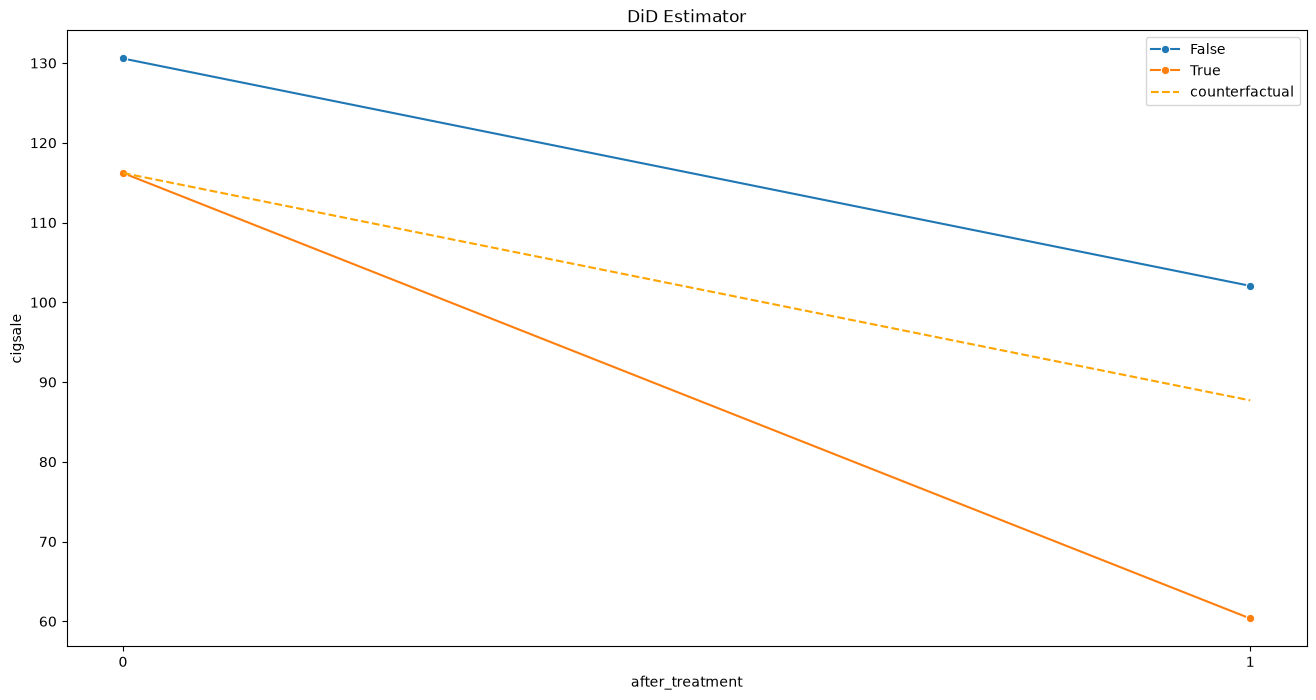

In [12]:
plt.figure(figsize = (16,8))
sns.lineplot(data = df.groupby(['california', 'after_treatment'])['cigsale'].mean().reset_index(),
            x = 'after_treatment', 
            y = 'cigsale', 
            hue = 'california', 
            marker = "o").set(xticks = [0,1])
plt.plot([False, True], [mu_before_treat, mu_before_treat + (mu_after_control - mu_before_control)], 
         label = "counterfactual",
        color = "orange", 
        linestyle = "dashed")
plt.legend()
plt.title("DiD Estimator")
plt.show()

The graph above show the means of each group *(treated = solid orange, control = blue)* for the before (0) and after (1) treatment periods. This actually represents the mean points in the table above. 

The new dashed orange line shows the inferred counterfactual the DiD estimator calculates. The DiD effect is the difference between the end of the solid orange line, and the end of the orange dotted line i.e: 

$$ Causal\ Effect = Actual - Counterfactual$$

You might notice that the counterfactual in this scenario basically looks like the control group, but shifted down to start from the treated groups initial mean value. 

You would be right to think that is interesting. An interesting follow up question might be how does the parallel trend assumption apply here? *(hint: is it reasonable to assume that this counterfactual will follow the same trend as the control group?)*.

## OLS
Now that we've explored what's going on under the hood, lets look at some other helpful ways to calculate the DiD estiamtor. 

Perhaps the most common way is to use OLS. Very handily, the above calcualtion can be simplified into a linear model. 

It involves the defining the binary variables:

$$
\ AfterTreatment_t = \begin{cases}
    1 & \text{if } t\ is\ after\ treatment \\
    0 & \text{otherwise.}
\end{cases}
$$

and:

$$
\ Treated_i = \begin{cases}
    1 & \text{if } i\ is\ the\ treated\ unit \\
    0 & \text{otherwise.}
\end{cases}
$$

If we put these variables into a matrix as such: 

$$
X = \begin{bmatrix}
1 & Teated_1 & AfterTreatment_1 & treated_1 \times AfterTreatment_1 \\
1 & Teated_2 & AfterTreatment_2 & treated_2 \times AfterTreatment_2 \\
1 & Teated_3 & AfterTreatment_3 & treated_3 \times AfterTreatment_3 \\
\vdots & \vdots & \vdots & \vdots  \\
1 & Teated_i & AfterTreatment_t & Treated_i \times AfterTreatment_t
\end{bmatrix}
$$

We can use the OLS estimator to calculate $\beta'$, and $\beta_3$ of that vector will be the DiD estimate.

Let's code this up:

In [13]:
panel = df.set_index(['state', 'year'])

In [14]:
print(lm.PooledOLS(panel[['cigsale']], 
            panel[['const',
                'treated',
                'post_treat',
                'treated_post_treat']]).fit(cov_type = "clustered", 
                                           cluster_entity = True).summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:                cigsale   R-squared:                        0.2073
Estimator:                  PooledOLS   R-squared (Between):              0.0228
No. Observations:                1209   R-squared (Within):               0.5310
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.2073
Time:                        16:37:23   Log-likelihood                   -5793.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      105.07
Entities:                          39   P-value                           0.0000
Avg Obs:                       31.000   Distribution:                  F(3,1205)
Min Obs:                       31.000                                           
Max Obs:                       31.000   F-statistic (robust):          1.171e+18
                            

As you can see the coefficeint for `treated_post_treat` is the same as the manual calculations above. If you look at the table below, you can see how the scenario corresponds to the four possible scenarios from the manual calculations: 

| Scenario | Time Period | Excise Tax Increase | Conditions ($Treated_i, AfterTreatment_t$) | Coefficient |
 | :--- | :--- | :--- | :--- | :--- | 
 | Control Group (Pre) | pre 1988 | No | $$Treated_i=0, AfterTreatment_t=0$$ | $$\beta_0$$ |
 | Control Group (Post) | post 1988 | No | $$Treated_i=0, AfterTreatment_t=1$$ | $$\beta_0 + \beta_2$$ | 
| Treatment Group (Pre) |  pre 1988 | Yes | $$Treated_i=1, AfterTreatment_t=0$$ | $$\beta_0 + \beta_1$$ |
| Treatment Group (Post) | post 1988 | Yes | $Treated_i=1, AfterTreatment_t=1$ | $\beta_0 + \beta_1 + \beta_2 + \beta_3$ | 


If we take the above and apply each coefficeint to the manual calculations we get:

$$
DiD = [(\beta_0 + \beta_1 + \beta_2 + \beta_3) - (\beta_0 + \beta_1)] - [(\beta_0 + \beta_2) - \beta_0]
$$

$$
DiD = \beta_2 + \beta_3 - \beta_2 = \beta_3
$$


## Fixed Effects (TWFE)

Note in the above that we get estimates for all of the the elements in $\beta$. This is obviously fine, but say we wanted to just get the $\beta_3$ coefficient?

Well, if we apply the "within" transformation to remove the "time- & unit-invariant" coefficients (and effects), we can calculate just the DiD estimate. Instead of including everything in the $X$ matrix above, we just include the varibale `treated_post_treat` and apply the within transformation to estimate $\beta_3$. 

Let's chose this up!

In [15]:
print(lm.PanelOLS(panel[['cigsale']], 
                  panel[['treated_post_treat']],
                  entity_effects = True, 
                  time_effects = True).fit(cov_type = "clustered", 
                                           cluster_entity = True).summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                cigsale   R-squared:                        0.0327
Estimator:                   PanelOLS   R-squared (Between):             -0.0037
No. Observations:                1209   R-squared (Within):               0.0360
Date:                Tue, Jun 23 2026   R-squared (Overall):             -0.0026
Time:                        16:37:23   Log-likelihood                   -4663.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      38.470
Entities:                          39   P-value                           0.0000
Avg Obs:                       31.000   Distribution:                  F(1,1139)
Min Obs:                       31.000                                           
Max Obs:                       31.000   F-statistic (robust):             94.515
                            

Yay, it's the same!

It's worth noting that none of these above estimates are "better" than one another. They are estimating the same coefficient and hence will have the same results *(note all three methods produce the 27.34 decrease in cigarette sales per capita)*.

The differences / benefits of each approach depends on what estimates you want to produce. By way of example, lets take a look at a popular choice using the TWFE approach that can estimate "dynamic" effects.

# Event Design Study

The general "event-study" designs in econometrics follows this general and flexible linear form:

$$ Y_{it} = \sum_{k\neq-1} \beta_k \times 1\{Treated = 1\} \times 1\{t = k\} + \alpha_i + \lambda_t + \varepsilon_{it}$$

Where $k$ is the treatment / intervention timeline i.e. $k=0$ is the time the intervention occours. 

In the above more we also have the typical time and unit fixed effects, yet we also have this interaction term where our estimates for $\beta_k$ are interaction with a dummary varibale for the treated unit, $1\{Treated = 1\}$, and dummy variables for each of the time periods in $k$, $1\{t = k\}$, i.e. a 1 for each time period in k, otherwise a zero. 

Note that $\beta_{r=-1}$ is not estimated because it acts as a "baseline year". 

It is really helpful to use TWFE in this model because all the other time and unit invariant terms will cancel out when we estimate using OLS and the within transformation. 

This means our model will produce one coefficient for each period in $k$, excluding the baseline year. 

This can make investigating how the effect develops over time quite simple (and visual). 

So, let's try and code this up!

In [16]:
# this nice little list compression probably looks scary, but it is basically just creating a list of years
# this list can then be used to create the necessary interaction columns 
# (have a look at the list that is printed oiut)
treated_cols = [col for col in pd.get_dummies(df['year'], prefix='year', drop_first=False).columns]
print(treated_cols)

for col in treated_cols:
    panel[f'treated_{col}'] = panel['treated'] * panel[col]

# we need to remove the year before the treatment starts to act as a baseline comparison (it will be zero)
interaction_terms = [f'treated_{col}' for col in treated_cols if col != 'year_1988']


['year_1970', 'year_1971', 'year_1972', 'year_1973', 'year_1974', 'year_1975', 'year_1976', 'year_1977', 'year_1978', 'year_1979', 'year_1980', 'year_1981', 'year_1982', 'year_1983', 'year_1984', 'year_1985', 'year_1986', 'year_1987', 'year_1988', 'year_1989', 'year_1990', 'year_1991', 'year_1992', 'year_1993', 'year_1994', 'year_1995', 'year_1996', 'year_1997', 'year_1998', 'year_1999', 'year_2000']


In [17]:
event_mod = lm.PanelOLS.from_formula(f"cigsale ~ {' + '.join(interaction_terms)} + EntityEffects + TimeEffects",
                         data = panel, drop_absorbed=True).fit(cov_type = 'clustered',cluster_entity = True)
print(event_mod.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                cigsale   R-squared:                        0.0430
Estimator:                   PanelOLS   R-squared (Between):             -0.0004
No. Observations:                1209   R-squared (Within):               0.0413
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.0007
Time:                        16:37:24   Log-likelihood                   -4657.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.6638
Entities:                          39   P-value                           0.0142
Avg Obs:                       31.000   Distribution:                 F(30,1110)
Min Obs:                       31.000                                           
Max Obs:                       31.000   F-statistic (robust):             37.992
                            

Amazing! We can see that in the first year after the excise was introduce, cigarette sales per capita immediate dropped by -3.5 packets per capita. By the year 2000, this has drop to -26.81 packets per capita (close to the base DiD estimate). 

This allows us to see that the effect didn't take place immedaitely post the introduction of the excise tax, but did take about a decade to reach it's full effect. 

Without this sort of dynamic estimates, we might have been lead to believe that the effect should be immediate. 

This has become quite a popular estimator in econometrics. One nice thing you can do with these estimates is graph it!

In [18]:
event_results = pd.merge(pd.DataFrame(event_mod.params).reset_index(), 
                         pd.DataFrame(event_mod.std_errors).reset_index(), 
                         how = "inner", 
                         on = "index").rename (columns = {"index" : "year"})

crit_value = 1.96
event_results["year"] = event_results['year'].str[-4:].astype(int)
event_results["upper"] = event_results["parameter"]  + crit_value * event_results["std_error"] 
event_results["lower"] = event_results["parameter"]  - crit_value * event_results["std_error"]

Text(0.5, 0, 'year')

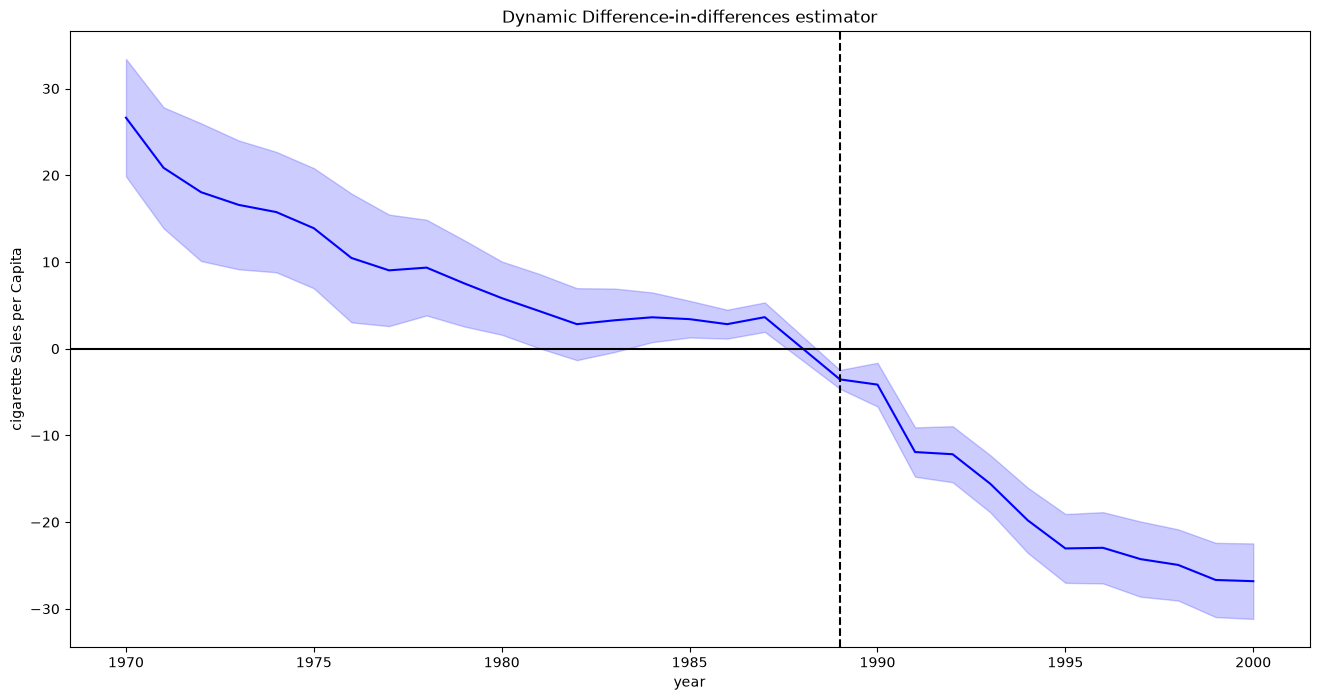

In [19]:
plt.figure(figsize = (16,8))
plt.plot(event_results['year'], event_results["parameter"], color = "blue")
plt.fill_between(event_results['year'], 
                 event_results['lower'], 
                 event_results['upper'], color = "blue", alpha = 0.2)
plt.axvline(x = 1989, color = "black", linestyle = "--")
plt.axhline(y = 0, color = "black", linestyle = "-")
plt.title("Dynamic Difference-in-differences estimator")
plt.ylabel("cigarette Sales per Capita")
plt.xlabel("year")

This is great, we can see the effect is trending down with a statistically significant effect post 1989. 

What is also of interest is that there appears to be a statistically significant effect pre the treatment as well! Why is that happening? 

Well, if we remember back to the key assumption of parallel trends, then we shouldn't really be seeing a statistically significant estiamte prior to treatment. However, we saw above that there is indeed a difference in the pre-treatment trends.

This graph shows that there was a measurable downward trend in cigarette sales prior to the introduciton of the excise tax, and thus we can't be certain that this entire effect wasn't just a continuation of this trend itself. 

One way to fix this issue is to relax the "parallel trends" assumption - but that requires another estimator for another day.